# BosonSR Annihilation:



## 0. Setup

In [17]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt

import annihilation2 as A2   # the corrected physics, used as-is

plt.rcParams['figure.figsize'] = (9, 4.5)
print("annihilation2 module loaded from:", A2.__file__)

annihilation2 module loaded from: /Users/chrisewasiuk/Desktop/3rd-Generation-Gravitational-Wave-Detector-Strain-Templates/chris/annihilation2.py


## 1. Self-test — confirm the physics before trusting anything downstream

Reuses the benchmark checks already built into `annihilation2.py`
(CAPP Eqs. 1/3/4, Yang & Huang Eq. 54's alpha^14 power scaling).

In [18]:
A2._run_self_tests()

SELF-TESTS vs published benchmarks
[1] f_line = 5.290e+09 Hz   (CAPP Eq.1 ~5.3e9 Hz)   PASS
[2] h0     = 1.059e-22    (CAPP Eq.3 ~1.0e-22)     PASS
[3] tau    = 11.32 days  (CAPP Eq.4 ~4.7 d)      PASS
[4] P ~ alpha^13.98    (Yang-Huang Eq.54 -> 14)    PASS
[5] h0 ~ alpha^6.99 (CAPP Eq.3 ->7)   tau ~ alpha^-14.98 (CAPP Eq.4 ->-15)   PASS
[6] SNR mono=8.124e+04 sampled=8.115e+04 (rel.diff 0.1%)  PASS


## 2. Waveform and parameters

Same smoke-test point as the original notebook: `M_solar=10, mua=2e-21`,
`dL = 1e-6 Gpc = 1 kpc`.

In [19]:
M_solar, mua = 10.0, 2.0e-21
dL_Gpc = 1.0e-6
KPC_TO_AU = 2.0626480624709618e8
distance_au = dL_Gpc * 1e9 * KPC_TO_AU     # Gpc -> kpc -> AU
iota, phase0 = 0.4, 0.0
T_obs = 4 * 86400.0   # coherent observation time assumed for this forecast

r0 = A2.iso_gatom_ann_strain(M_solar=M_solar, mua=mua, distance_au=distance_au,
                              iota=iota, phase=phase0, T_obs_s=T_obs, verbose=True)

alpha            = 1.4967e-01
mu_a             = 2.0000e-21 GeV
M_a / M_b        = 7.4834e-02
f_line           = 9.6448e+02 Hz
P (GW power)     = 2.8758e+22 GeV^2
h0 (char strain) = 7.0589e-26
tau (duration)   = 1.9105e+10 s = 221126.372 days
fdot (drift)     = 9.1507e-04 Hz/s
Delta_f_eff      = 3.1625e+02 Hz


## 4. Detector response

A standard long-wavelength-limit antenna pattern (`F+`, `F×` as a function of
sky position `theta, phi` and polarization angle `psi`), and a widely used
analytic approximation to the aLIGO zero-detuned high-power design noise PSD
(Ajith et al.), as a stand-in for a real detector noise curve.

corrected band: (9.644798e+02, 9.644802e+02) Hz,  width = 3.472e-04 Hz,  4001 pts


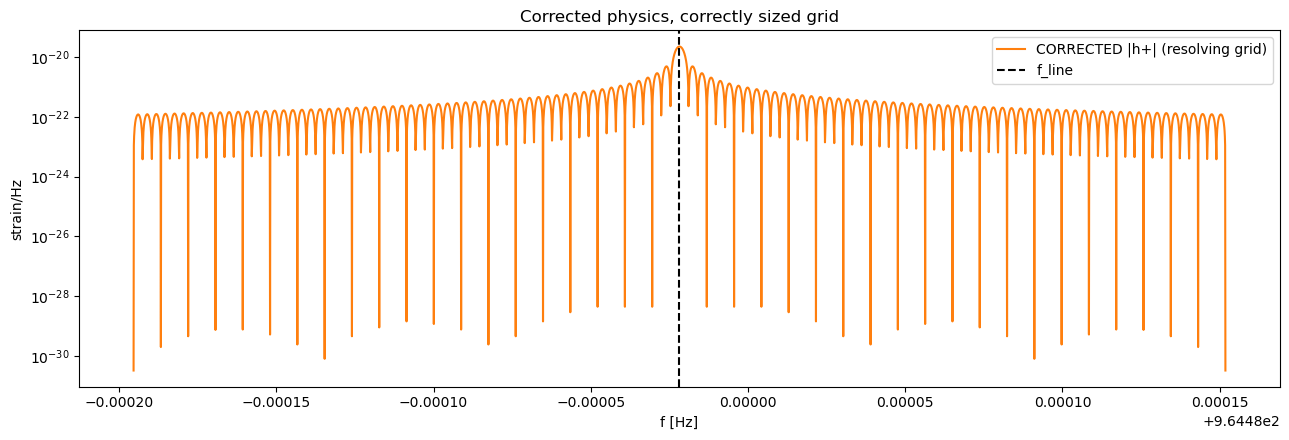

In [31]:


f_line = r0['f_line_Hz']
tau = r0['tau_s']
T_coh = min(T_obs, tau)



nwidths = 60.0
half = nwidths / T_coh
fmin_new, fmax_new = max(2.0, f_line - half), f_line + half
f_new = np.linspace(fmin_new, fmax_new, 4001)
hp_new, hc_new = A2.sampled_strain(f_new, f_line, r0['h_plus'], r0['h_cross'], T_obs, tau)


print(f"corrected band: ({fmin_new:.6e}, {fmax_new:.6e}) Hz,  width = {fmax_new-fmin_new:.3e} Hz,  4001 pts")


fig, axs = plt.subplots(1, 1, figsize=(13, 4.5))


plt.plot(f_new, np.abs(hp_new), label='CORRECTED |h+| (resolving grid)', color='C1')
plt.axvline(f_line, ls='--', c='k', label='f_line')
plt.yscale('log'); plt.xlabel('f [Hz]'); plt.ylabel('strain/Hz')
plt.title('Corrected physics, correctly sized grid'); plt.legend()
plt.tight_layout(); plt.show()

F+ = 0.3312, Fx = -0.4856
S_n(f_line=964.5 Hz) = 1.840e-46 1/Hz


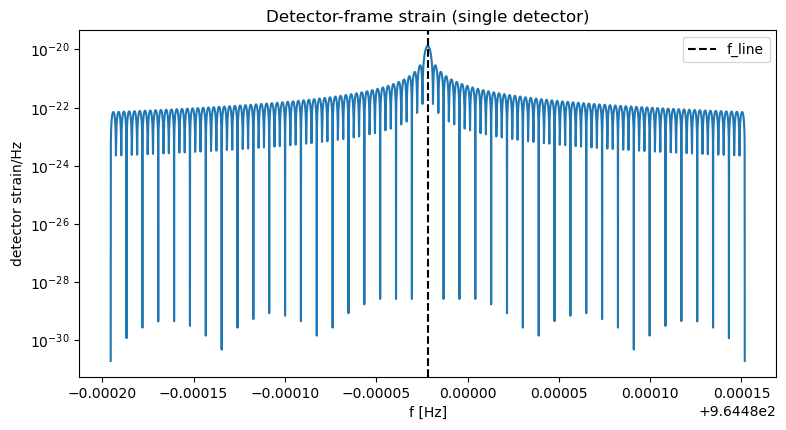

In [21]:
def antenna_pattern(theta, phi, psi):
    Fp = 0.5*(1+np.cos(theta)**2)*np.cos(2*phi)*np.cos(2*psi) - np.cos(theta)*np.sin(2*phi)*np.sin(2*psi)
    Fx = 0.5*(1+np.cos(theta)**2)*np.cos(2*phi)*np.sin(2*psi) + np.cos(theta)*np.sin(2*phi)*np.cos(2*psi)
    return Fp, Fx

def S_n_aLIGO(f):
    # Ajith et al. analytic approximation to the aLIGO zero-detuned high-power PSD [1/Hz]
    f = np.asarray(f, dtype=float)
    x = f / 215.0
    return 1e-49 * (x**-4.14 - 5*x**-2 + 111*(1 - x**2 + 0.5*x**4)/(1 + 0.5*x**2))

theta, phi, psi = 1.0, 2.0, 0.7
Fp, Fx = antenna_pattern(theta, phi, psi)
print(f"F+ = {Fp:.4f}, Fx = {Fx:.4f}")
print(f"S_n(f_line={f_line:.1f} Hz) = {S_n_aLIGO(f_line):.3e} 1/Hz")

h_det = Fp*hp_new + Fx*hc_new
plt.plot(f_new, np.abs(h_det))
plt.axvline(f_line, ls='--', c='k', label='f_line')
plt.yscale('log'); plt.xlabel('f [Hz]'); plt.ylabel('detector strain/Hz')
plt.title('Detector-frame strain (single detector)'); plt.legend(); plt.show()

## 5. SNR across the (M_solar, mua) grid

Same range as the original notebook (`M_solar in [1,100]`, `mua in
[2e-22,2e-21]`, 12x12), masked wherever `alpha > 0.5` (outside Yang & Huang
Eq. 54's validity).

finite SNR everywhere valid: True
alpha range on grid: 0.0014966732511185763 .. 1.496673251118576


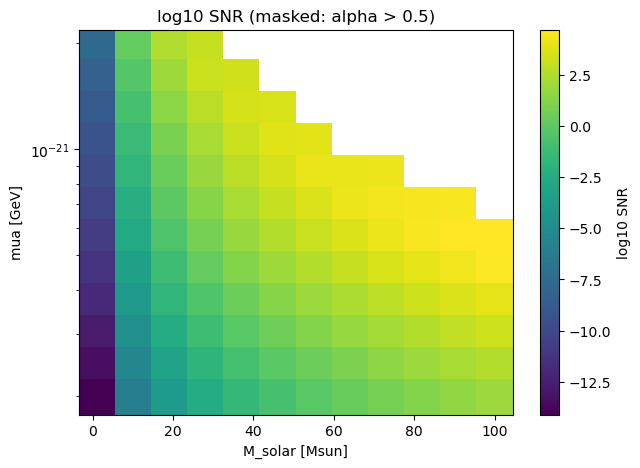

In [22]:
M_grid = np.linspace(1.0, 100.0, 12)
mua_grid = 2.0 * 10.0**np.linspace(-22, -21, 12)

snr_matrix = np.full((len(M_grid), len(mua_grid)), np.nan)
alpha_matrix = np.full_like(snr_matrix, np.nan)

for i, M in enumerate(M_grid):
    for j, mu in enumerate(mua_grid):
        alpha = A2.alpha_of(M, mu)
        alpha_matrix[i, j] = alpha
        if not (0 < alpha <= 0.5):
            continue
        rr = A2.iso_gatom_ann_strain(M_solar=M, mua=mu, distance_au=distance_au,
                                      iota=iota, phase=phase0, T_obs_s=T_obs, verbose=False)
        Fp_, Fx_ = antenna_pattern(theta, phi, psi)
        h_plus, h_cross = rr['h_plus'], rr['h_cross']
        snr_matrix[i, j] = A2.snr_monochromatic(
            Fp_*h_plus, Fx_*h_cross, rr['f_line_Hz'], T_obs, S_n_aLIGO, tau_s=rr['tau_s'])

valid = (alpha_matrix > 0) & (alpha_matrix <= 0.5)
print("finite SNR everywhere valid:", np.all(np.isfinite(snr_matrix[valid])))
print("alpha range on grid:", np.nanmin(alpha_matrix), "..", np.nanmax(alpha_matrix))

plot_snr = np.where(valid, snr_matrix, np.nan)
plt.figure(figsize=(7,5))
plt.pcolormesh(M_grid, mua_grid, np.log10(plot_snr).T, shading='auto')
plt.yscale('log'); plt.xlabel('M_solar [Msun]'); plt.ylabel('mua [GeV]')
plt.title('log10 SNR (masked: alpha > 0.5)')
plt.colorbar(label='log10 SNR')
plt.show()

## 6. Fisher matrix — single detector

The analytic method: differentiate the smooth scalars (`h0`, `f_line`)
directly, and resolve only the `sinc` line *shape* on the frequency grid —
not a naive finite difference of a sampled line, which is what breaks down
when the line moves by less than one grid cell.

alpha = 0.1496673251118576   f_line = 964.4799782133448 Hz
finite everywhere: True
fraction of entries that are nonzero: 1.0
(the uploaded screenshot's matrix was ~2/81 nonzero entries -- effectively empty)


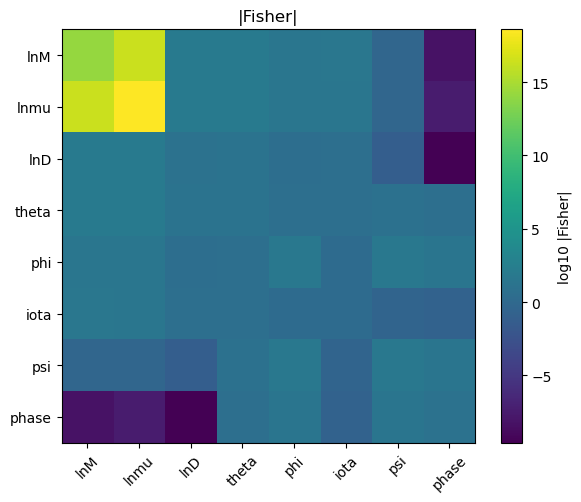

In [23]:
PARAMS = ['lnM', 'lnmu', 'lnD', 'theta', 'phi', 'iota', 'psi', 'phase']

def scalars(M_solar, mua, D_au, theta, phi, iota, psi, phase):
    rr = A2.iso_gatom_ann_strain(M_solar=M_solar, mua=mua, distance_au=D_au,
                                  iota=iota, phase=phase, verbose=False)
    Fp_, Fx_ = antenna_pattern(theta, phi, psi)
    h_det = Fp_*rr['h_plus'] + Fx_*rr['h_cross']
    return h_det, rr['f_line_Hz'], rr

def fisher_single(M_solar, mua, D_au=distance_au, theta=1.0, phi=2.0, iota=0.4, psi=0.7,
                   phase=0.3, T_obs=T_obs, nwidths=60.0, Nf=8001, h=1e-6, psd=S_n_aLIGO):
    h0det, f0, r0_ = scalars(M_solar, mua, D_au, theta, phi, iota, psi, phase)
    Tcoh = min(T_obs, r0_['tau_s'])
    f = np.linspace(f0 - nwidths/Tcoh, f0 + nwidths/Tcoh, Nf)
    W = Tcoh * np.sinc((f - f0) * Tcoh)
    dWdf = np.gradient(W, f)

    fid = dict(M_solar=M_solar, mua=mua, D_au=D_au, theta=theta, phi=phi, iota=iota, psi=psi, phase=phase)
    def perturb(p, s):
        kw = dict(fid)
        if p == 'lnM':    kw['M_solar'] = M_solar * np.exp(s)
        elif p == 'lnmu': kw['mua']     = mua * np.exp(s)
        elif p == 'lnD':  kw['D_au']    = D_au * np.exp(s)
        elif p == 'theta':kw['theta']   = theta + s
        elif p == 'phi':  kw['phi']     = phi + s
        elif p == 'iota': kw['iota']    = iota + s
        elif p == 'psi':  kw['psi']     = psi + s
        elif p == 'phase':kw['phase']   = phase + s
        return scalars(**kw)[:2]

    dh = []
    for p in PARAMS:
        (Ap, fp), (Am, fm) = perturb(p, h), perturb(p, -h)
        dA  = (Ap - Am) / (2*h)
        df0 = (fp - fm) / (2*h)
        dh.append(dA*W - h0det*dWdf*df0)

    Snf = psd(f0)
    n = len(PARAMS); F = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            F[i, j] = 4.0 * np.real(np.trapezoid(np.conj(dh[i])*dh[j], f)) / Snf
    return F, r0_

def precondition(F):
    d = 1.0/np.sqrt(np.diag(F))
    D = np.diag(d)
    return D @ F @ D, D

F_single, r0_ = fisher_single(M_solar, mua)
print("alpha =", r0_['alpha'], "  f_line =", r0_['f_line_Hz'], "Hz")
print("finite everywhere:", np.all(np.isfinite(F_single)))
print("fraction of entries that are nonzero:", np.mean(np.abs(F_single) > 1e-30*np.max(np.abs(F_single))))
print("(the uploaded screenshot's matrix was ~2/81 nonzero entries -- effectively empty)")

Fs_single, _ = precondition(F_single)
plt.figure(figsize=(6,5))
plt.imshow(np.log10(np.abs(F_single)+1e-300), cmap='viridis')
plt.xticks(range(8), PARAMS, rotation=45); plt.yticks(range(8), PARAMS)
plt.colorbar(label='log10 |Fisher|')
plt.title('|Fisher|')
plt.tight_layout(); plt.show()